In [5]:
import pandas as pd
import numpy as np
import yaml
import os.path as osp
import copy

from calisim.data_model import (
	DistributionModel,
	ParameterDataType,
	ParameterSpecification,
)
 
from calisim.uncertainty import (
	UncertaintyAnalysisMethod,
	UncertaintyAnalysisMethodModel,
)
import pcse
from pcse.models import Wofost72_PP
from pcse.base import ParameterProvider
from pcse.input import NASAPowerWeatherDataProvider, YAMLAgroManagementReader, YAMLCropDataProvider, WOFOST72SiteDataProvider, DummySoilDataProvider


In [6]:
wdp = NASAPowerWeatherDataProvider(latitude=52, longitude=5)
print(wdp)

Weather data provided by: NASAPowerWeatherDataProvider
--------Description---------
NASA/POWER Source Native Resolution Daily Data
----Site characteristics----
Elevation:    3.5
Latitude:  52.000
Longitude:  5.000
Data available for 1984-01-01 - 2025-10-21
Number of missing days: 0



In [7]:
sited = WOFOST72SiteDataProvider(WAV=50)
print(sited)

{'IFUNRN': 0, 'NOTINF': 0, 'SSI': 0.0, 'SSMAX': 0.0, 'WAV': 50.0, 'SMLIM': 0.4}


In [8]:
soild = DummySoilDataProvider()
print(soild)

{'SMFCF': 0.3, 'SM0': 0.4, 'SMW': 0.1, 'RDMSOL': 120, 'CRAIRC': 0.06, 'K0': 10.0, 'SOPE': 10.0, 'KSUB': 10.0}


In [12]:
cropd = YAMLCropDataProvider(fpath=osp.join("..", "data"), force_reload=True)
print(cropd)

Crop parameters loaded from: /mnt/c/Users/james/projects/wofost-bdd/data
Crop and variety not set: no active crop parameter set!



In [10]:
agro = YAMLAgroManagementReader(osp.join("..", "data", "AGMT_C2_2020.agro"))
print(agro)

!!python/object/new:pcse.input.yaml_agro_loader.YAMLAgroManagementReader
listitems:
- 2020-04-20:
    CropCalendar:
      crop_end_date: 2020-11-03
      crop_end_type: maturity
      crop_name: potato
      crop_start_date: 2020-04-20
      crop_start_type: sowing
      max_duration: 300
      variety_name: Potato_C2_C5
    StateEvents: null
    TimedEvents: null



In [13]:
params = ParameterProvider(cropdata=cropd, sitedata=sited, soildata=soild)
wofost = Wofost72_PP(params, wdp, agro)
wofost.run_till_terminate()
observed_data = pd.DataFrame(wofost.get_output())
observed_data

,day,DVS,LAI,TAGP,TWSO,TWLV,TWST,TWRT,TRA,RD,SM,WWLOW
0,2020-04-20,-0.100000,0.120000,60.00000,0.000000,48.000000,12.000000,15.000000,0.000000,10.0,0.3,None
1,2020-04-21,-0.097173,0.120000,60.00000,0.000000,48.000000,12.000000,15.000000,0.000000,10.0,0.3,None
2,2020-04-22,-0.093882,0.120000,60.00000,0.000000,48.000000,12.000000,15.000000,0.000000,10.0,0.3,None
3,2020-04-23,-0.090047,0.120000,60.00000,0.000000,48.000000,12.000000,15.000000,0.000000,10.0,0.3,None
4,2020-04-24,-0.085667,0.120000,60.00000,0.000000,48.000000,12.000000,15.000000,0.000000,10.0,0.3,None
...,...,...,...,...,...,...,...,...,...,...,...,...
140,2020-09-07,1.963323,0.876336,16447.03535,11629.712391,3077.106707,1740.216253,1135.030442,0.128282,50.0,0.3,None
141,2020-09-08,1.972529,0.876336,16447.03535,11629.712391,3077.106707,1740.216253,1135.030442,0.088088,50.0,0.3,None
142,2020-09-09,1.982916,0.716347,16447.03535,11629.712391,3077.106707,1740.216253,1135.030442,0.085369,50.0,0.3,None
143,2020-09-10,1.992974,0.581502,16447.03535,11629.712391,3077.106707,1740.216253,1135.030442,0.071436,50.0,0.3,None


<Axes: xlabel='day', ylabel='LAI'>

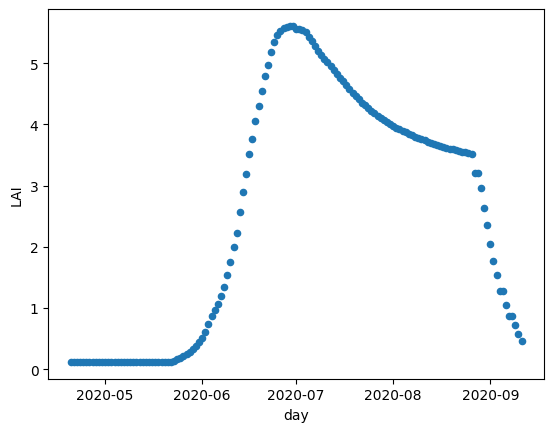

In [14]:
observed_data.plot.scatter("day", "LAI")